## Install TabPFN

In [1]:
# Pinned: an unpinned install let two runs of an unchanged notebook resolve
# different TabPFN packages, checkpoints, and preprocessing defaults, which made
# run-to-run score differences uninterpretable. The rest of the stack is
# recorded in the run manifest rather than pinned, so Kaggle's preinstalled
# numpy/torch build is left alone.
TABPFN_PIN = "9.0.0"  # first release exposing the v3.5 checkpoint
TABPFN_CLIENT_PIN = "0.6.0"  # first release exposing the hosted v3.5 model

!pip install -q -q --no-warn-conflicts tabpfn=={TABPFN_PIN} tabpfn-client=={TABPFN_CLIENT_PIN}


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 827.5/827.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 595.9/595.9 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.6/781.6 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.0 MB/s eta 0:00:00


## Ready Env

In [2]:
import os
from pathlib import Path

KAGGLE_RAW_CSV = "/kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv"
KAGGLE_RESULT_SUBDIR = "modeling_results"
is_kaggle_env = os.path.isdir("/kaggle/working")


def _find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for d in (here, *here.parents):
        if (d / "data" / "raw" / "VLST.csv").is_file():
            return d
    raise FileNotFoundError("Could not locate data/raw/VLST.csv above cwd.")


def _discover_vlst_csv() -> Path:
    env = os.environ.get("VLST_RAW_CSV")
    if env and Path(env).is_file():
        return Path(env)
    for p in (
            Path(KAGGLE_RAW_CSV),
            Path("/kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv"),
            Path("/kaggle/input/vlst-data/VLST.csv"),
            Path("/kaggle/input/datasets/amirinho661/vlst-figshare-7409606/VLST.csv")
    ):
        if p.is_file():
            return p
    base = Path("/kaggle/input")
    if base.is_dir():
        for p in base.rglob("VLST.csv"):
            if p.is_file():
                return p
    raise FileNotFoundError(
        "VLST.csv not found. On Kaggle, add the vlst-data dataset or set VLST_RAW_CSV."
    )


def _resolve_paths():
    if is_kaggle_env:
        raw = _discover_vlst_csv()
        result = Path(
            os.environ.get(
                "VLST_RESULT_DIR",
                str(Path("/kaggle/working") / KAGGLE_RESULT_SUBDIR),
            )
        )
        return raw, result, "Kaggle"
    repo = _find_repo_root()
    return (
        Path(os.environ.get("VLST_RAW_CSV", repo / "data" / "raw" / "VLST.csv")),
        Path(os.environ.get("VLST_RESULT_DIR", repo / "data" / "result" / "modeling_results")),
        "local",
    )


def _load_tabpfn_tokens():
    hf = os.environ.get("HF_TOKEN", "").strip()
    tabpfn = os.environ.get("TABPFN_TOKEN", "").strip()
    if tabpfn:
        return hf, tabpfn

    from kaggle_secrets import UserSecretsClient
    secrets = UserSecretsClient()
    hf = secrets.get_secret("HF_TOKEN")
    tabpfn = secrets.get_secret("AMIRINHO661_TABPFN_TOKEN")
    return hf, tabpfn


RAW_PATH, RESULT_DIR, _runtime = _resolve_paths()
FIGURE_DIR = RESULT_DIR / "figures"
TABLE_DIR = RESULT_DIR / "tables"
OOF_DIR = RESULT_DIR / "oof"
for _path in (RESULT_DIR, FIGURE_DIR, TABLE_DIR, OOF_DIR):
    _path.mkdir(parents=True, exist_ok=True)

try:
    import torch

    CUDA_AVAILABLE = torch.cuda.is_available()
    DEVICE_NAME = torch.cuda.get_device_name(0) if CUDA_AVAILABLE else "cpu"
except Exception:
    CUDA_AVAILABLE = False
    DEVICE_NAME = "cpu"

CATBOOST_TASK_TYPE = "GPU" if CUDA_AVAILABLE else "CPU"
XGB_DEVICE = "cuda" if CUDA_AVAILABLE else "cpu"
LGB_DEVICE = "gpu" if CUDA_AVAILABLE else "cpu"

_hf_token, _tabpfn_token = _load_tabpfn_tokens()
if _tabpfn_token:
    os.environ["TABPFN_TOKEN"] = _tabpfn_token
if _hf_token:
    os.environ["HF_TOKEN"] = _hf_token

print("Runtime:", _runtime)
print("RAW_PATH:", RAW_PATH)
print("RESULT_DIR:", RESULT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)
print("TABLE_DIR:", TABLE_DIR)
print("OOF_DIR:", OOF_DIR)
print("CUDA:", CUDA_AVAILABLE, "|", DEVICE_NAME)
print("CatBoost:", CATBOOST_TASK_TYPE, "| XGB:", XGB_DEVICE)
print("are TOKENs ready:", bool(_tabpfn_token) and bool(_hf_token))


Runtime: Kaggle
RAW_PATH: /kaggle/input/datasets/amirinho661/vlst-figshare-7409606/VLST.csv
RESULT_DIR: /kaggle/working/modeling_results
FIGURE_DIR: /kaggle/working/modeling_results/figures
TABLE_DIR: /kaggle/working/modeling_results/tables
OOF_DIR: /kaggle/working/modeling_results/oof
CUDA: True | Tesla T4
CatBoost: GPU | XGB: cuda
are TOKENs ready: True


## Fit and Eval

Classics use library defaults plus class weighting. The inner loop tunes only the F1 threshold.
`GridSearchCV` winners from `baseline_without_tssi.ipynb` are **not** imported.

**File-level cleaning (same status as dropping TSSI).** Identifiers,
`Time since stent implantation`, and `WBC` are dropped. Remaining labs whose
*recording precision* is a case/control batch marker are quantized to a
**pre-specified clinical grid**. Stent-brand collapse (`min_count=30`) is fit on
each **training fold only**; held-out strings map to `other`. Follow-up drugs
(`Aspirin`, `Clopidogrel`, `Ticagrelor`, `DAPT`) **stay in**. Re-run before
quoting any score; stored OOF below is from the old file.

Comparison on the same nested-CV protocol:
- **Classics** — library defaults plus class weighting.
- **TabPFN v3** and **TabPFN v3.5** — `from tabpfn import TabPFNClassifier`, one arm per explicitly
  named checkpoint, no thinking. Same folds, same seed, same preprocessing, so the only difference
  between the two arms is the checkpoint.
- **TabPFN thinking v3** and **TabPFN thinking v3.5** — `tabpfn_client.TabPFNClassifier` with
  `thinking_mode=True`, one arm per hosted checkpoint, so the version comparison covers the
  hosted path too. Every hosted fit spends fit quota.

Every arm is on in `RUN_MODELS`; set one False to skip it.


In [3]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score, roc_auc_score, roc_curve, f1_score, fbeta_score,
    accuracy_score, precision_score, recall_score,
    confusion_matrix, precision_recall_curve,
)

# Baseline Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
# Hosted client, used for the thinking-mode arms. The local package is optional below.
from tabpfn_client import TabPFNClassifier


def _environment_manifest():
    """Capture everything a TabPFN score depends on outside this notebook.

    Distribution metadata is used instead of ``module.__version__`` because
    ``tabpfn_client`` does not expose one.
    """
    import hashlib
    import platform
    from importlib.metadata import PackageNotFoundError, version as _distribution_version

    packages = {}
    for distribution in (
        "tabpfn",
        "tabpfn-client",
        "scikit-learn",
        "numpy",
        "pandas",
        "xgboost",
        "lightgbm",
        "catboost",
        "torch",
    ):
        try:
            packages[distribution] = _distribution_version(distribution)
        except PackageNotFoundError:
            packages[distribution] = None

    raw_sha256 = hashlib.sha256(Path(RAW_PATH).read_bytes()).hexdigest()
    print("Package versions:", "; ".join(f"{k}={v}" for k, v in packages.items()))
    print("Python:", platform.python_version(), "| raw CSV sha256:", raw_sha256)
    return {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "runtime": _runtime,
        "cuda": CUDA_AVAILABLE,
        "device": DEVICE_NAME,
        "packages": packages,
        "raw_csv": str(RAW_PATH),
        "raw_csv_sha256": raw_sha256,
    }


ENV_MANIFEST = _environment_manifest()

LOCAL_TABPFN_AVAILABLE = False
LocalTabPFNClassifier = None
try:
    from tabpfn import TabPFNClassifier as LocalTabPFNClassifier

    LOCAL_TABPFN_AVAILABLE = True
except Exception as exc:
    print("Local TabPFN not importable; skipping that arm:", exc)


def _load_stent_encoding():
    """Import the shared 9-level stent-brand encoder.

    On Kaggle the repo tree is usually missing, so this falls back to an
    in-notebook copy of ``code/modeling/tools/stent_encoding.py``.
    """
    import re
    import sys
    from pathlib import Path

    search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for extra in (
        Path("/kaggle/working"),
        Path("/kaggle/input"),
        Path("/kaggle/usr/lib"),
    ):
        if extra.is_dir():
            search_roots.append(extra)
            search_roots.extend(extra.glob("*"))

    for d in search_roots:
        for tools in (
            d / "code" / "modeling" / "tools",
            d / "modeling" / "tools",
            d,
        ):
            if (Path(tools) / "stent_encoding.py").is_file():
                tools = Path(tools)
                if str(tools) not in sys.path:
                    sys.path.insert(0, str(tools))
                try:
                    from stent_encoding import (
                        encode_stent_brand_column,
                        coerce_stent_class_flags,
                        fit_stent_brand_encoder,
                        transform_stent_brand_column,
                    )
                except ImportError:
                    continue
                print("Stent encoder: imported from", tools / "stent_encoding.py")
                return (
                    encode_stent_brand_column,
                    coerce_stent_class_flags,
                    fit_stent_brand_encoder,
                    transform_stent_brand_column,
                )

    print("Stent encoder: using in-notebook fallback (Kaggle / no repo tree).")

    STENT_BRAND_RAW_COL = "Stent type-SES"
    STENT_CLASS_FLAG_COLS = ("PES", "ZES", "EVS")
    STENT_BRAND_MIN_COUNT = 30
    _BRAND_ALIASES = {
        "xiencex": "xiencev",
        "resolut": "resolute",
        "parnter": "partner",
        "endeavor": "endeavor",
        "cypher": "cypher",
    }

    def canonicalize_stent_brand(value):
        if pd.isna(value) or str(value).strip() == "":
            return "missing"
        s = str(value).strip().replace("：", ":").lower()
        s = re.sub(r"\s+", "", s)
        if ":" in s:
            s = s.split(":")[-1]
        for sep in ("，", ",", "/"):
            if sep in s:
                s = s.split(sep)[0]
        return _BRAND_ALIASES.get(s, s)

    def collapse_rare_brands(series, min_count=STENT_BRAND_MIN_COUNT):
        counts = series.value_counts()
        rare = set(counts[counts < min_count].index)
        if not rare:
            return series
        return series.where(~series.isin(rare), "other")

    def encode_stent_brand_column(df, *, raw_col=STENT_BRAND_RAW_COL, min_count=STENT_BRAND_MIN_COUNT, inplace=False):
        out = df if inplace else df.copy()
        meta = {
            "column": raw_col,
            "n_raw": 0,
            "n_levels": 0,
            "min_count": min_count,
            "applied": False,
            "value_counts": {},
        }
        if raw_col not in out.columns:
            return out, meta
        raw = out[raw_col]
        if pd.api.types.is_numeric_dtype(raw):
            meta["n_raw"] = int(raw.nunique(dropna=True))
            meta["n_levels"] = meta["n_raw"]
            return out, meta
        n_raw = int(raw.nunique(dropna=True))
        encoded = collapse_rare_brands(raw.map(canonicalize_stent_brand), min_count)
        out[raw_col] = encoded.astype("object")
        meta.update({
            "n_raw": n_raw,
            "n_levels": int(encoded.nunique(dropna=True)),
            "applied": True,
            "value_counts": encoded.value_counts().to_dict(),
        })
        return out, meta

    def coerce_stent_class_flags(df):
        out = df
        for col in STENT_CLASS_FLAG_COLS:
            if col not in out.columns:
                continue
            s = pd.to_numeric(out[col], errors="coerce").fillna(0).astype(int)
            bad = ~s.isin([0, 1])
            if bad.any():
                raise ValueError(f"{col}: expected 0/1 after coercion, got {out.loc[bad, col].unique()[:10]}")
            out[col] = s
        return out

    def fit_stent_brand_encoder(series, min_count=STENT_BRAND_MIN_COUNT):
        meta = {
            "min_count": min_count,
            "numeric": False,
            "kept": set(),
            "n_raw": 0,
            "n_levels": 0,
            "applied": False,
            "value_counts": {},
        }
        if pd.api.types.is_numeric_dtype(series):
            n = int(series.nunique(dropna=True))
            meta.update({"numeric": True, "n_raw": n, "n_levels": n})
            return meta
        canon = series.map(canonicalize_stent_brand)
        counts = canon.value_counts()
        kept = set(counts[counts >= min_count].index)
        meta.update({
            "kept": kept,
            "n_raw": int(series.nunique(dropna=True)),
            "n_levels": int(len(kept) + int((counts < min_count).any())),
            "applied": True,
            "value_counts": counts.to_dict(),
        })
        return meta

    def transform_stent_brand_column(frame, codebook, raw_col=STENT_BRAND_RAW_COL, inplace=False):
        out = frame if inplace else frame.copy()
        if raw_col not in out.columns or codebook.get("numeric") or not codebook.get("applied"):
            return out
        canon = out[raw_col].map(canonicalize_stent_brand)
        kept = codebook["kept"]
        out[raw_col] = canon.where(canon.isin(kept), "other").astype("object")
        return out

    return (
        encode_stent_brand_column,
        coerce_stent_class_flags,
        fit_stent_brand_encoder,
        transform_stent_brand_column,
    )


(
    encode_stent_brand_column,
    coerce_stent_class_flags,
    fit_stent_brand_encoder,
    transform_stent_brand_column,
) = _load_stent_encoding()

STENT_BRAND_COL = "Stent type-SES"


def encode_stent_on_fold(X_train, X_val, raw_col=STENT_BRAND_COL, min_count=30):
    """Collapse rare brands from training counts only. Unseen val brands -> other."""
    if raw_col not in X_train.columns:
        return X_train, X_val, {"applied": False, "n_raw": 0, "n_levels": 0, "min_count": min_count}
    codebook = fit_stent_brand_encoder(X_train[raw_col], min_count=min_count)
    return (
        transform_stent_brand_column(X_train, codebook, raw_col=raw_col),
        transform_stent_brand_column(X_val, codebook, raw_col=raw_col),
        codebook,
    )


# 1. Load and validate data
df = pd.read_csv(RAW_PATH)
df = coerce_stent_class_flags(df)
if STENT_BRAND_COL in df.columns:
    print(
        f"Stent brand left as raw strings "
        f"({int(df[STENT_BRAND_COL].nunique(dropna=True))} unique); "
        "rare-brand collapse is fit inside each CV training fold."
    )
TARGET = "Stent thrombosis"

# Pre-declared clinical grids for labs whose raw text precision is a
# case/control batch marker (see the leakage-probe cell). Same status as
# dropping TSSI: a file-level cleaning rule, not a parameter fit on y.
# Places are the coarsest grid that is still a standard report for the
# stored SI unit — matching the coarser typing convention so case-only
# extra decimals cannot identify the outcome.
#   Cre 0 dp  — µmol/L; integer is standard
#   CaI 2 dp  — ng/mL conventional TnI; refuse case-only thousandths
#               (do not round CaI to 0: that is not a clinical TnI report)
#   Fiberinogen / Fast-Glu 1 dp — g/L and mmol/L
# WBC is dropped entirely (lattice + magnitude). HGB/Platelet text formats
# differ ("146" vs "146.00") but collapse to the same float after read_csv.
CLINICAL_QUANTIZE_PLACES = {
    "Cre": 0,
    "CaI": 2,
    "Fiberinogen": 1,
    "Fast-Glu": 1,
}


def quantize_clinical_precision(frame, places_by_column):
    """Round listed numeric columns in-place; return the columns actually changed."""
    applied = {}
    for column, places in places_by_column.items():
        if column not in frame.columns:
            continue
        if not pd.api.types.is_numeric_dtype(frame[column]):
            continue
        before = pd.to_numeric(frame[column], errors="coerce")
        rounded = before.round(int(places))
        frame[column] = rounded
        n_changed = int((before != rounded).fillna(False).sum())
        applied[column] = {"places": int(places), "n_changed": n_changed}
    return applied


_quantize_applied = quantize_clinical_precision(df, CLINICAL_QUANTIZE_PLACES)
print(
    "Clinical quantization (file-level, before split):",
    ", ".join(
        f"{col}->{meta['places']}dp ({meta['n_changed']} values changed)"
        for col, meta in _quantize_applied.items()
    )
    or "(no listed columns present)",
)

DROP_FEATURES = [
    "NO.",
    "Name",
    "Time since stent implantation",
    "WBC",
]
X = df.drop(columns=[*DROP_FEATURES, TARGET], errors="ignore")
y = df[TARGET].astype(int)
if set(y.unique()) != {0, 1}:
    raise ValueError(f"{TARGET!r} must contain exactly the binary labels 0 and 1.")

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "string", "bool"]).columns.tolist()
if len(numeric_features) + len(categorical_features) != X.shape[1]:
    unsupported = sorted(set(X.columns) - set(numeric_features) - set(categorical_features))
    raise TypeError(f"Unsupported feature dtypes for columns: {unsupported}")

# 2. Preprocessing is cloned and fitted independently inside every CV split.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
]).set_output(transform="pandas")


def lightgbm_safe_frame(data):
    """Use stable feature names accepted by LightGBM's JSON model format."""
    frame = data.copy() if isinstance(data, pd.DataFrame) else pd.DataFrame(data)
    frame.columns = [f"feature_{index}" for index in range(frame.shape[1])]
    return frame


# 3. Model templates. Average precision (PR-AUC) is the common metric.
# LogisticRegression and RandomForestClassifier have no internal eval_metric;
# both are evaluated with average_precision_score on outer OOF predictions.
#
# GridSearch winners from baseline_without_tssi.ipynb are NOT imported here.
# The inner loop only chooses an F1 threshold.
# Set a flag False to skip an arm.
#
# Local checkpoints compared side by side. Each is named explicitly because
# model_path="auto" does not mean "newest": in tabpfn 9.0.0 it still resolves to v3,
# so the default would quietly run the older checkpoint under a v3.5 label.
# "v3.5-fast" is the cheaper sibling if fit time becomes the constraint.
TABPFN_MODEL_VERSIONS = ("v3", "v3.5")

# Hosted thinking arms, one per checkpoint. Every hosted fit spends fit quota, and the
# nested protocol costs OUTER_SPLITS * (INNER_SPLITS + 1) = 25 fits per arm, so trim this
# tuple to a single version when quota is tight.
TABPFN_THINKING_VERSIONS = ("v3", "v3.5")

RUN_MODELS = {
    "Logistic Regression": True,
    "Random Forest": True,
    "XGBoost": True,
    "LightGBM": True,
    "CatBoost": True,
}
# One local arm per checkpoint ("TabPFN v3") and one hosted thinking arm per checkpoint
# ("TabPFN thinking v3").
RUN_MODELS.update({f"TabPFN {_v}": True for _v in TABPFN_MODEL_VERSIONS})
RUN_MODELS.update({f"TabPFN thinking {_v}": True for _v in TABPFN_THINKING_VERSIONS})

models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("clf", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("clf", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("clf", XGBClassifier(
            random_state=42,
            eval_metric="aucpr",
            tree_method="hist",
            device=XGB_DEVICE,
            n_jobs=1 if XGB_DEVICE == "cuda" else -1,
        ))
    ]),
    "LightGBM": Pipeline([
        ("preprocessor", preprocessor),
        ("safe_feature_names", FunctionTransformer(lightgbm_safe_frame, validate=False)),
        ("clf", LGBMClassifier(
            class_weight="balanced",
            metric="average_precision",
            random_state=42,
            verbose=-1,
            device=LGB_DEVICE,
            n_jobs=1 if LGB_DEVICE == "gpu" else -1,
        ))
    ]),
    "CatBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("clf", CatBoostClassifier(
            auto_class_weights="Balanced",
            eval_metric="PRAUC",
            random_state=42,
            verbose=0,
            task_type=CATBOOST_TASK_TYPE,
            **({"devices": "0"} if CATBOOST_TASK_TYPE == "GPU" else {}),
        ))
    ]),
}

# Hosted thinking arms. thinking_metric matches the metric this notebook reports, so the
# fit-time search optimises the same quantity; it runs inside each training split, but it
# has to be disclosed alongside the score.
THINKING_KWARGS = {
    "thinking_mode": True,
    "thinking_effort": "high",
    "thinking_metric": "average_precision",
    "random_state": 42,
}
CLIENT_TABPFN_MODELS = {}
for _version in TABPFN_THINKING_VERSIONS:
    _arm = f"TabPFN thinking {_version}"
    try:
        _client_clf = TabPFNClassifier.create_default_for_version(_version, **THINKING_KWARGS)
    except (AttributeError, ValueError) as exc:
        # Client too old to name this checkpoint. Leaving model_path unset would run
        # whatever the server defaults to, so skip rather than label a guess as a version.
        print(
            f"Cannot select hosted TabPFN {_version} ({type(exc).__name__}: {exc}); arm skipped. "
            f"Install tabpfn-client=={TABPFN_CLIENT_PIN} to run it."
        )
        continue
    _served = _client_clf.get_params().get("model_path")
    if _served in (None, "auto", "default"):
        print(f"WARNING: {_arm} deferred to the server default; arm skipped rather than mislabelled.")
        continue
    models[_arm] = _client_clf
    CLIENT_TABPFN_MODELS[_arm] = str(_served)
    print(
        f"{_arm} ready |",
        f"server model={_served}",
        f"effort={THINKING_KWARGS['thinking_effort']}",
        f"metric={THINKING_KWARGS['thinking_metric']}",
    )

# Two arms on one served model would report a version difference that does not exist.
if len(set(CLIENT_TABPFN_MODELS.values())) != len(CLIENT_TABPFN_MODELS):
    raise ValueError(f"Hosted thinking arms share a model: {CLIENT_TABPFN_MODELS}")

# The v3.5 weights live in the gated Prior-Labs/tabpfn_3_5 HF repo, so HF_TOKEN must
# belong to an account that has accepted that repo's terms.
LOCAL_TABPFN_CHECKPOINTS = {}
if LOCAL_TABPFN_AVAILABLE:
    _local_device = "cuda" if CUDA_AVAILABLE else "cpu"

    def build_local_tabpfn(version):
        """Build a local arm on a named checkpoint, or None if the package lacks it."""
        # n_estimators default is "auto" (starts at 8). Passing -1 yields
        # num_estimators=0 and crashes in generate_classification_ensemble_configs.
        kwargs = {
            "device": _local_device,
            "n_estimators": "auto",
            "random_state": 42,
        }
        try:
            from tabpfn.constants import ModelVersion

            return LocalTabPFNClassifier.create_default_for_version(
                ModelVersion(version), **kwargs
            )
        except (ImportError, AttributeError, ValueError) as exc:
            # Older tabpfn whose ModelVersion has no entry for this checkpoint. Skipping
            # the arm beats silently scoring a different model under this name.
            print(
                f"Cannot select TabPFN {version} ({type(exc).__name__}: {exc}); arm skipped. "
                f"Install tabpfn=={TABPFN_PIN} to run it."
            )
            return None

    for _version in TABPFN_MODEL_VERSIONS:
        _arm = f"TabPFN {_version}"
        _classifier = build_local_tabpfn(_version)
        if _classifier is None:
            continue
        _params = _classifier.get_params()
        _checkpoint = _params.get("model_path")
        if _checkpoint == "auto":
            print(f"WARNING: {_arm} is unpinned; arm skipped rather than mislabelled.")
            continue
        models[_arm] = _classifier
        LOCAL_TABPFN_CHECKPOINTS[_arm] = str(_checkpoint)
        print(
            f"{_arm} ready |",
            f"checkpoint={Path(_checkpoint).name}",
            f"device={_params.get('device')}",
            f"n_estimators={_params.get('n_estimators')}",
            f"balance_probabilities={_params.get('balance_probabilities')}",
            f"ignore_pretraining_limits={_params.get('ignore_pretraining_limits')}",
        )

    # Two arms on one file would report a version difference that does not exist.
    if len(set(LOCAL_TABPFN_CHECKPOINTS.values())) != len(LOCAL_TABPFN_CHECKPOINTS):
        raise ValueError(f"Local TabPFN arms share a checkpoint: {LOCAL_TABPFN_CHECKPOINTS}")
elif any(RUN_MODELS.get(f"TabPFN {_v}") for _v in TABPFN_MODEL_VERSIONS):
    print("Local TabPFN arms requested but `tabpfn` is not installed; skipped.")

models = {name: spec for name, spec in models.items() if RUN_MODELS.get(name, True)}
if not models:
    raise ValueError("RUN_MODELS left no models to fit.")
print("Nested-CV arms:", ", ".join(models))

ENV_MANIFEST.update(
    {
        "arms": list(models),
        "tabpfn_local_versions_requested": list(TABPFN_MODEL_VERSIONS),
        "tabpfn_local_checkpoints": LOCAL_TABPFN_CHECKPOINTS,
        "tabpfn_thinking_versions_requested": list(TABPFN_THINKING_VERSIONS),
        "tabpfn_thinking_models": CLIENT_TABPFN_MODELS,
        "tabpfn_thinking_settings": THINKING_KWARGS,
    }
)
_manifest_path = Path(RESULT_DIR) / "run_manifest.json"
_manifest_path.write_text(json.dumps(ENV_MANIFEST, indent=2))
print("Saved run manifest to:", _manifest_path)
print(f"Classic GPU routing: CatBoost={CATBOOST_TASK_TYPE}, XGB={XGB_DEVICE}, LGB={LGB_DEVICE}")


def fresh_model(model_name, model_template, y_fit):
    """Clone a model and derive label-dependent settings from training data only."""
    model = clone(model_template)
    if model_name == "XGBoost":
        n_positive = int((y_fit == 1).sum())
        n_negative = int((y_fit == 0).sum())
        if n_positive == 0:
            raise ValueError("XGBoost training split contains no positive cases.")
        model.set_params(clf__scale_pos_weight=n_negative / n_positive)
    return model


def optimal_f1_threshold(y_true, probabilities):
    """Choose an F1 threshold using only the supplied calibration labels."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, probabilities)
    if thresholds.size == 0:
        return 0.5
    f1_values = (
            2 * precisions[:-1] * recalls[:-1]
            / (precisions[:-1] + recalls[:-1] + 1e-10)
    )
    return float(thresholds[int(np.argmax(f1_values))])


# 4. Nested CV: tune thresholds on inner OOF predictions and apply each
# threshold once to that outer fold's unseen validation cases.
OUTER_SPLITS = 5
INNER_SPLITS = 4
outer_cv = StratifiedKFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=42)
oof_probabilities = {name: np.zeros(len(X), dtype=float) for name in models}
oof_binary_predictions = {name: np.zeros(len(X), dtype=int) for name in models}
fold_thresholds = {name: [] for name in models}
oof_fold_ids = np.zeros(len(X), dtype=int)

print(f"Running nested {OUTER_SPLITS}-fold outer / {INNER_SPLITS}-fold inner CV...")
for outer_fold, (train_idx, val_idx) in enumerate(outer_cv.split(X, y), 1):
    print(f"Processing outer fold {outer_fold}/{OUTER_SPLITS}...")
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val = X.iloc[val_idx]
    oof_fold_ids[val_idx] = outer_fold
    inner_cv = StratifiedKFold(
        n_splits=INNER_SPLITS,
        shuffle=True,
        random_state=10_000 + outer_fold,
    )

    for model_name, model_template in models.items():
        print(f"  {model_name}: estimating threshold from inner OOF predictions")
        inner_oof_probabilities = np.zeros(len(X_train), dtype=float)
        for inner_train_idx, calibration_idx in inner_cv.split(X_train, y_train):
            X_inner_train = X_train.iloc[inner_train_idx]
            y_inner_train = y_train.iloc[inner_train_idx]
            X_calibration = X_train.iloc[calibration_idx]
            X_inner_enc, X_cal_enc, _ = encode_stent_on_fold(X_inner_train, X_calibration)
            inner_model = fresh_model(model_name, model_template, y_inner_train)
            inner_model.fit(X_inner_enc, y_inner_train)
            inner_oof_probabilities[calibration_idx] = inner_model.predict_proba(X_cal_enc)[:, 1]

        fold_threshold = optimal_f1_threshold(y_train, inner_oof_probabilities)
        fold_thresholds[model_name].append(fold_threshold)
        X_train_enc, X_val_enc, stent_meta = encode_stent_on_fold(X_train, X_val)
        if model_name == next(iter(models)):
            print(
                f"  Stent brand (outer-train only): {stent_meta.get('n_raw')} raw -> "
                f"{stent_meta.get('n_levels')} levels (min_count={stent_meta.get('min_count')})"
            )
        outer_model = fresh_model(model_name, model_template, y_train)
        outer_model.fit(X_train_enc, y_train)
        val_probabilities = outer_model.predict_proba(X_val_enc)[:, 1]
        oof_probabilities[model_name][val_idx] = val_probabilities
        oof_binary_predictions[model_name][val_idx] = (
                val_probabilities >= fold_threshold
        ).astype(int)

print("Nested CV finished.")
print("OOF arrays ready for:", ", ".join(oof_probabilities))
print("Next cells plot ranking curves, confusion matrices, and the comparison table.")


def restore_tabpfn_empirical_prior(labels):
    """Invert a class-frequency reweight on already-scored TabPFN OOF.

    p_raw = (p * pi1) / (p * pi1 + (1-p) * pi0). Idempotent: skips when the
    mean predicted probability is already near prevalence. Nested hard labels
    are unchanged because the map is monotone.
    """
    # Local arms only ("TabPFN v3", "TabPFN v3.5"); the client arm is left alone.
    names = [n for n in oof_probabilities if n.startswith("TabPFN v")]
    if not names:
        return
    y_arr = np.asarray(labels, dtype=float)
    prior = float(y_arr.mean())
    for name in names:
        p = np.asarray(oof_probabilities[name], dtype=float)
        if prior <= 0.0 or p.mean() <= 4.0 * prior:
            continue
        pi0 = 1.0 - prior
        denom = np.clip(p * prior + (1.0 - p) * pi0, 1e-12, None)
        restored = np.clip(p * prior / denom, 0.0, 1.0)
        brier_before = float(np.mean((p - y_arr) ** 2))
        brier_after = float(np.mean((restored - y_arr) ** 2))
        oof_probabilities[name] = restored
        if name in fold_thresholds:
            t = np.asarray(fold_thresholds[name], dtype=float)
            t_denom = np.clip(t * prior + (1.0 - t) * pi0, 1e-12, None)
            fold_thresholds[name] = np.clip(t * prior / t_denom, 0.0, 1.0).tolist()
        print(
            f"{name}: restored empirical prior "
            f"(mean {p.mean():.4f} -> {restored.mean():.4f}; "
            f"Brier {brier_before:.4f} -> {brier_after:.4f}). "
            "PR-AUC/ROC unchanged; nested hard labels unchanged."
        )


restore_tabpfn_empirical_prior(y)


Package versions: tabpfn=9.0.0; tabpfn-client=0.6.0; scikit-learn=1.6.1; numpy=2.0.2; pandas=2.3.3; xgboost=3.2.0; lightgbm=4.6.0; catboost=1.2.10; torch=2.10.0+cu128
Python: 3.12.13 | raw CSV sha256: 0b8cf3da4064496a6702b0d0b5736e80306a2b8c141f9d8a9d896cbfab00d93e
Stent encoder: using in-notebook fallback (Kaggle / no repo tree).
Stent brand left as raw strings (106 unique); rare-brand collapse is fit inside each CV training fold.
Clinical quantization (file-level, before split): Cre->0dp (3063 values changed), CaI->2dp (32 values changed), Fiberinogen->1dp (4369 values changed), Fast-Glu->1dp (4346 values changed)
TabPFN thinking v3 ready | server model=v3_default effort=high metric=average_precision
TabPFN thinking v3.5 ready | server model=v3.5_default effort=high metric=average_precision
TabPFN v3 ready | checkpoint=tabpfn-v3-classifier-v3_default.ckpt device=cuda n_estimators=auto balance_probabilities=False ignore_pretraining_limits=False
TabPFN v3.5 ready | checkpoint=tabpfn-v3

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [21:24:11] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


  LightGBM: estimating threshold from inner OOF predictions


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


  CatBoost: estimating threshold from inner OOF predictions


...

  TabPFN thinking v3: estimating threshold from inner OOF predictions
  TabPFN thinking v3.5: estimating threshold from inner OOF predictions
  TabPFN v3: estimating threshold from inner OOF predictions
  TabPFN v3.5: estimating threshold from inner OOF predictions
Processing outer fold 4/5...
  Logistic Regression: estimating threshold from inner OOF predictions
  Stent brand (outer-train only): 95 raw -> 9 levels (min_count=30)
  Random Forest: estimating threshold from inner OOF predictions
  XGBoost: estimating threshold from inner OOF predictions
  LightGBM: estimating threshold from inner OOF predictions
  CatBoost: estimating threshold from inner OOF predictions


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


  TabPFN thinking v3: estimating threshold from inner OOF predictions
  TabPFN thinking v3.5: estimating threshold from inner OOF predictions
  TabPFN v3: estimating threshold from inner OOF predictions
  TabPFN v3.5: estimating threshold from inner OOF predictions
Processing outer fold 5/5...
  Logistic Regression: estimating threshold from inner OOF predictions
  Stent brand (outer-train only): 101 raw -> 9 levels (min_count=30)
  Random Forest: estimating threshold from inner OOF predictions
  XGBoost: estimating threshold from inner OOF predictions
  LightGBM: estimating threshold from inner OOF predictions
  CatBoost: estimating threshold from inner OOF predictions


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


  TabPFN thinking v3: estimating threshold from inner OOF predictions
  TabPFN thinking v3.5: estimating threshold from inner OOF predictions
  TabPFN v3: estimating threshold from inner OOF predictions
  TabPFN v3.5: estimating threshold from inner OOF predictions
Nested CV finished.
OOF arrays ready for: Logistic Regression, Random Forest, XGBoost, LightGBM, CatBoost, TabPFN thinking v3, TabPFN thinking v3.5, TabPFN v3, TabPFN v3.5
Next cells plot ranking curves, confusion matrices, and the comparison table.


## Leakage diagnostics

The raw file is sorted by outcome — all 92 cases are the last 92 rows — and those cases were
transcribed at a different numeric precision than the controls, so recording precision alone
partly identifies the outcome.

The raw file is sorted by outcome — all 92 cases are the last 92 rows — and those cases were
transcribed at a different numeric precision than the controls, so recording precision alone
partly identifies the outcome.

The fit cell drops `WBC` with TSSI, quantizes other leaking labs on the whole file
before the split, and fits stent-brand collapse on each **training fold only**.
Follow-up drugs stay in the model matrix. The probe cell still reads **raw**
`VLST.csv` (including WBC) so it documents the artefact that was in the file.


In [4]:
# Probe: how much of the headline PR-AUC is reachable with no clinical information?
#
# Every lab value is written at a source-specific precision, and the 92 cases were
# transcribed under a different convention from the controls (no case has a
# whole-number WBC; ~74% of controls do). That signature survives `read_csv` into
# the floats every arm trains on, so it acts as a proxy for "which source produced
# this row" — a perfect predictor of the outcome in this file. Keeping only the
# signature and discarding the magnitudes puts a floor on the artefact available to
# the arms above: the probe is a plain GBM, while TabPFN reads fine-grained value
# structure considerably better than threshold splits do.

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_predict

PROBE_DECIMALS = (0, 1, 2)
# Probe still reads the raw file, including WBC, so it documents the artefact
# that was in VLST.csv. Models never see WBC (DROP_FEATURES).
EXCLUDED_COLUMNS = ["NO.", "Name", TARGET]
MODEL_DROP_COLUMNS = list(DROP_FEATURES) + [TARGET] if "DROP_FEATURES" in globals() else [
    "NO.", "Name", "Time since stent implantation", "WBC", TARGET,
]
_y = np.asarray(y, dtype=int)


def precision_grid_features(frame, columns, decimals=PROBE_DECIMALS):
    """Indicators for "this parsed float lies on a 10**-k grid"."""
    indicators = {}
    for column in columns:
        values = pd.to_numeric(frame[column], errors="coerce").to_numpy(dtype=float)
        if np.isnan(values).mean() > 0.5:
            continue
        thousandths = np.round(values * 1000.0)
        for places in decimals:
            step = 10 ** (3 - places)
            indicators[f"{column}__{places}dp"] = np.where(
                np.isnan(values), -1.0, (thousandths % step == 0).astype(float)
            )
    return pd.DataFrame(indicators, index=frame.index)


_probe_source = pd.read_csv(RAW_PATH)
probe_columns = [c for c in _probe_source.columns if c not in EXCLUDED_COLUMNS]
probe_features = precision_grid_features(_probe_source, probe_columns)

probe_probabilities = cross_val_predict(
    HistGradientBoostingClassifier(random_state=42),
    probe_features.to_numpy(dtype=float),
    _y,
    cv=StratifiedKFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=42),
    method="predict_proba",
)[:, 1]
probe_ap = float(average_precision_score(_y, probe_probabilities))
probe_auc = float(roc_auc_score(_y, probe_probabilities))

print(f"Precision-signature probe: {probe_features.shape[1]} indicators, no clinical magnitudes")
print(f"  AP = {probe_ap:.3f} | ROC-AUC = {probe_auc:.3f} | prevalence = {_y.mean():.4f}")
# A ratio at or above 1.0 means the arm scores no better than the artefact alone.
print("Each arm's AP against the probe:")
for _name, _probabilities in oof_probabilities.items():
    _ap = float(average_precision_score(_y, _probabilities))
    print(f"  {_name:<24} AP = {_ap:.3f} | probe/arm ratio = {probe_ap / max(_ap, 1e-12):.2f}")

print("\nStrongest single indicators:")
_ranked = []
for _column in probe_features.columns:
    _values = probe_features[_column].to_numpy(dtype=float)
    _auc = float(roc_auc_score(_y, _values))
    _ranked.append((max(_auc, 1.0 - _auc), _column, _values))
for _score, _column, _values in sorted(_ranked, key=lambda row: row[0], reverse=True)[:8]:
    print(
        f"  {_column:<28} AUC = {_score:.3f}"
        f"  cases {_values[_y == 1].mean():.2f} vs controls {_values[_y == 0].mean():.2f}"
    )

probe_path = TABLE_DIR / "leakage_precision_probe.csv"
pd.DataFrame(
    [{"probe": "precision_signature_only", "n_features": int(probe_features.shape[1]),
      "ap": probe_ap, "roc_auc": probe_auc, "prevalence": float(_y.mean())}]
).to_csv(probe_path, index=False)
print("\nSaved", probe_path)


Precision-signature probe: 243 indicators, no clinical magnitudes
  AP = 0.427 | ROC-AUC = 0.952 | prevalence = 0.0177
Each arm's AP against the probe:
  Logistic Regression      AP = 0.260 | probe/arm ratio = 1.64
  Random Forest            AP = 0.351 | probe/arm ratio = 1.22
  XGBoost                  AP = 0.632 | probe/arm ratio = 0.68
  LightGBM                 AP = 0.627 | probe/arm ratio = 0.68
  CatBoost                 AP = 0.571 | probe/arm ratio = 0.75
  TabPFN thinking v3       AP = 0.832 | probe/arm ratio = 0.51
  TabPFN thinking v3.5     AP = 0.921 | probe/arm ratio = 0.46
  TabPFN v3                AP = 0.715 | probe/arm ratio = 0.60
  TabPFN v3.5              AP = 0.896 | probe/arm ratio = 0.48

Strongest single indicators:
  WBC__0dp                     AUC = 0.871  cases 0.00 vs controls 0.74
  WBC__1dp                     AUC = 0.799  cases 0.21 vs controls 0.81
  CaI__2dp                     AUC = 0.619  cases 0.76 vs controls 1.00
  Cre__0dp                     AUC 

In [5]:
# Sensitivity re-fit: flatten the precision signature the probe isolates, by rounding
# every numeric column to the coarsest precision its raw text ever uses, then refit and
# compare. Only threshold-free metrics are compared, so the inner threshold loop is
# skipped. Hosted thinking arms are excluded because a second pass over the outer folds
# costs another OUTER_SPLITS hosted fits each — add them back once quota allows.

SENSITIVITY_ARMS = [name for name in models if "thinking" not in name.lower()]


def _text_decimal_places(series):
    text = series.fillna("").astype(str).str.strip()
    return text.str.extract(r"\.(\d+)$")[0].fillna("").str.len().astype(int)


def precision_equalise(text_frame, numeric_frame, columns):
    """Round each column to the coarsest precision present anywhere in it."""
    equalised = numeric_frame.copy()
    rounded_to = {}
    for column in columns:
        if not pd.api.types.is_numeric_dtype(numeric_frame[column]):
            continue
        places = _text_decimal_places(text_frame[column])
        coarsest = int(places.min())
        if int(places.max()) == coarsest:
            continue
        equalised[column] = pd.to_numeric(numeric_frame[column], errors="coerce").round(coarsest)
        rounded_to[column] = coarsest
    return equalised, rounded_to


_text_frame = pd.read_csv(RAW_PATH, dtype=str)
_equalised_frame = pd.read_csv(RAW_PATH)
_equalised_frame = coerce_stent_class_flags(_equalised_frame)
_equalised_frame, equalised_columns = precision_equalise(_text_frame, _equalised_frame, probe_columns)
X_equalised = _equalised_frame.drop(columns=MODEL_DROP_COLUMNS, errors="ignore")
if list(X_equalised.columns) != list(X.columns):
    raise ValueError("Equalised design matrix does not match the fitted one column-for-column.")
print(f"Equalised {len(equalised_columns)} column(s) to their coarsest precision: {equalised_columns}")

_sensitivity_cv = StratifiedKFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=42)
sensitivity_rows = []
for model_name in SENSITIVITY_ARMS:
    equalised_oof = np.zeros(len(X_equalised), dtype=float)
    for train_idx, val_idx in _sensitivity_cv.split(X_equalised, y):
        refit = fresh_model(model_name, models[model_name], y.iloc[train_idx])
        X_eq_train, X_eq_val, _ = encode_stent_on_fold(
            X_equalised.iloc[train_idx], X_equalised.iloc[val_idx]
        )
        refit.fit(X_eq_train, y.iloc[train_idx])
        equalised_oof[val_idx] = refit.predict_proba(X_eq_val)[:, 1]
    sensitivity_rows.append({
        "model": model_name,
        "ap_as_is": float(average_precision_score(_y, oof_probabilities[model_name])),
        "ap_equalised": float(average_precision_score(_y, equalised_oof)),
        "auc_as_is": float(roc_auc_score(_y, oof_probabilities[model_name])),
        "auc_equalised": float(roc_auc_score(_y, equalised_oof)),
    })
    _row = sensitivity_rows[-1]
    print(f"  {model_name:<24} AP {_row['ap_as_is']:.3f} -> {_row['ap_equalised']:.3f}"
          f" | ROC-AUC {_row['auc_as_is']:.3f} -> {_row['auc_equalised']:.3f}")

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df["ap_drop"] = sensitivity_df["ap_as_is"] - sensitivity_df["ap_equalised"]
sensitivity_path = TABLE_DIR / "precision_equalised_sensitivity.csv"
sensitivity_df.to_csv(sensitivity_path, index=False)
print("Saved", sensitivity_path)
print(
    "\nEqualising removes the precision signature but not the rest of the case/control\n"
    "provenance difference, so a small drop here does not clear the cohort concern."
)


Equalised 15 column(s) to their coarsest precision: {'Min-stent diameter': 0, 'Max-stent diameter': 0, 'CaI': 0, 'WBC': 0, 'HGB': 0, 'Platelet': 0, 'Cre': 0, 'eGFR': 1, 'TCL': 1, 'LDL': 1, 'HDL': 1, 'TG': 0, 'Fast-Glu': 1, 'HbA1c': 0, 'Fiberinogen': 1}
  Logistic Regression      AP 0.260 -> 0.254 | ROC-AUC 0.865 -> 0.867
  Random Forest            AP 0.351 -> 0.255 | ROC-AUC 0.888 -> 0.902
  XGBoost                  AP 0.632 -> 0.581 | ROC-AUC 0.937 -> 0.935
  LightGBM                 AP 0.627 -> 0.571 | ROC-AUC 0.944 -> 0.951


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


  CatBoost                 AP 0.571 -> 0.465 | ROC-AUC 0.940 -> 0.929
  TabPFN v3                AP 0.715 -> 0.731 | ROC-AUC 0.973 -> 0.973
  TabPFN v3.5              AP 0.896 -> 0.844 | ROC-AUC 0.992 -> 0.988
Saved /kaggle/working/modeling_results/tables/precision_equalised_sensitivity.csv

Equalising removes the precision signature but not the rest of the case/control
provenance difference, so a small drop here does not clear the cohort concern.


## Persist OOF

Write nested-CV out-of-fold labels, probabilities, fold IDs, and inner-CV thresholds to disk so later figures can be rebuilt without re-fitting.


In [6]:
OOF_DIR = Path(RESULT_DIR) / "oof"
OOF_DIR.mkdir(parents=True, exist_ok=True)

if "oof_fold_ids" not in globals():
    oof_fold_ids = np.zeros(len(y), dtype=int)
    _fold_splitter = StratifiedKFold(
        n_splits=OUTER_SPLITS, shuffle=True, random_state=42
    )
    for _fold, (_, _val_idx) in enumerate(_fold_splitter.split(X, y), 1):
        oof_fold_ids[_val_idx] = _fold


def _oof_col(name):
    """"TabPFN v3.5" -> "tabpfn_v3_5"; dots and dashes make awkward CSV headers."""
    return name.lower().replace(" ", "_").replace(".", "_").replace("-", "_")


oof_df = pd.DataFrame({"y": np.asarray(y, dtype=int), "fold": oof_fold_ids})
for _name in oof_probabilities:
    _key = _oof_col(_name)
    oof_df[f"{_key}_prob"] = np.asarray(oof_probabilities[_name], dtype=float)
    oof_df[f"{_key}_pred"] = np.asarray(oof_binary_predictions[_name], dtype=int)

n_folds_saved = len(next(iter(fold_thresholds.values())))
fold_thr_df = pd.DataFrame(fold_thresholds)
fold_thr_df.insert(0, "fold", np.arange(1, n_folds_saved + 1))

oof_csv = OOF_DIR / "oof_predictions.csv"
thr_csv = OOF_DIR / "fold_thresholds.csv"
oof_df.to_csv(oof_csv, index=False)
fold_thr_df.to_csv(thr_csv, index=False)
print("Saved OOF predictions to:", oof_csv)
print("Saved fold thresholds to:", thr_csv)
print(
    "OOF rows:", len(oof_df),
    "| positives:", int(oof_df["y"].sum()),
    "| folds:", sorted(oof_df["fold"].unique().tolist()),
)


Saved OOF predictions to: /kaggle/working/modeling_results/oof/oof_predictions.csv
Saved fold thresholds to: /kaggle/working/modeling_results/oof/fold_thresholds.csv
OOF rows: 5185 | positives: 92 | folds: [1, 2, 3, 4, 5]


## Ranking curves

Precision-recall and ROC curves from nested-CV out-of-fold probabilities (threshold-independent). The dotted line on the PR panel is the positive-class prevalence.


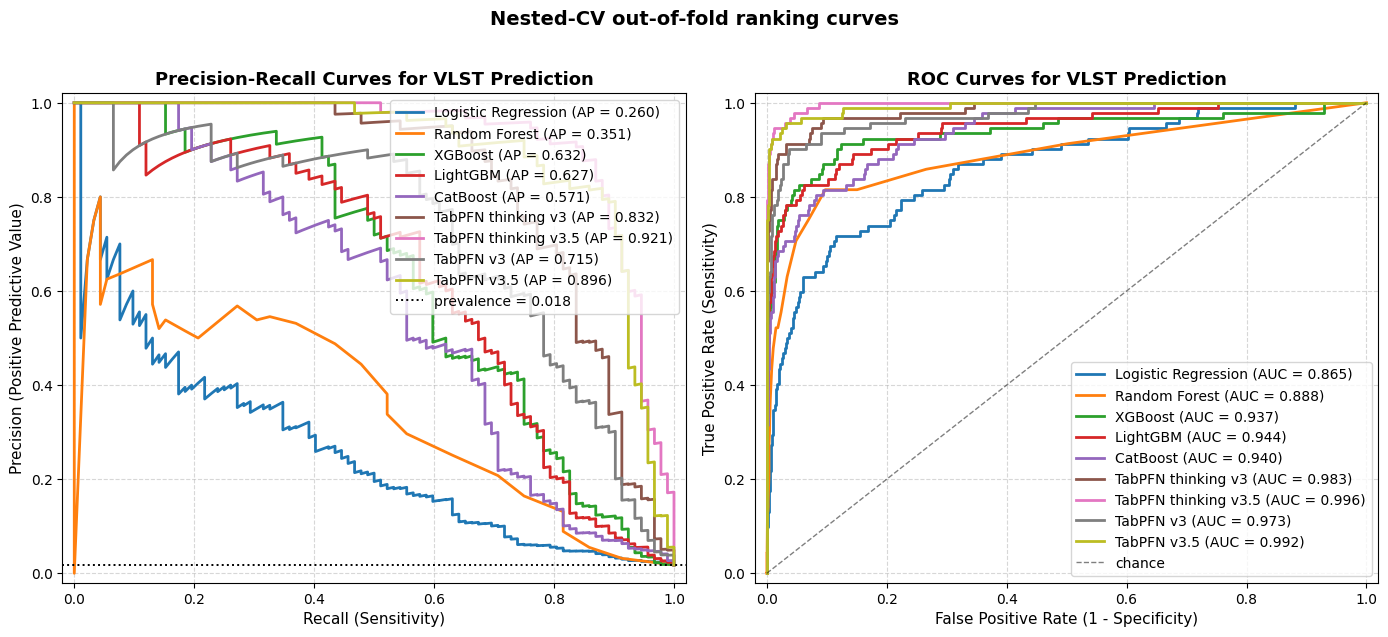

Saved ranking-curve panel to: /kaggle/working/modeling_results/figures/pr_roc_curves.png
Positive-class prevalence: 0.0177


In [7]:
y_true_oof = np.asarray(y)
THRESHOLD_GRID = np.linspace(0.01, 0.99, 199)
prevalence = float(np.mean(y_true_oof))


def best_fbeta_threshold(y_true, scores, beta=1.0, grid=THRESHOLD_GRID):
    best_t, best_s = 0.5, -1.0
    scores = np.asarray(scores)
    for t in grid:
        pred = (scores >= t).astype(int)
        score = fbeta_score(y_true, pred, beta=beta, zero_division=0)
        if score > best_s:
            best_s, best_t = score, float(t)
    return best_t


fig, axes = plt.subplots(1, 2, figsize=(14, 6.2))
for model_name, probabilities in oof_probabilities.items():
    precisions, recalls, _ = precision_recall_curve(y_true_oof, probabilities)
    ap = average_precision_score(y_true_oof, probabilities)
    axes[0].plot(recalls, precisions, lw=2, label=f"{model_name} (AP = {ap:.3f})")

    fpr, tpr, _ = roc_curve(y_true_oof, probabilities)
    auc = roc_auc_score(y_true_oof, probabilities)
    axes[1].plot(fpr, tpr, lw=2, label=f"{model_name} (AUC = {auc:.3f})")

axes[0].axhline(prevalence, color="k", ls=":", lw=1.4, label=f"prevalence = {prevalence:.3f}")
axes[0].set_xlabel("Recall (Sensitivity)", fontsize=11)
axes[0].set_ylabel("Precision (Positive Predictive Value)", fontsize=11)
axes[0].set_title("Precision-Recall Curves for VLST Prediction", fontsize=13, fontweight="bold")
axes[0].legend(loc="upper right")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].set_xlim(-0.02, 1.02)
axes[0].set_ylim(-0.02, 1.02)

axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="chance")
axes[1].set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
axes[1].set_ylabel("True Positive Rate (Sensitivity)", fontsize=11)
axes[1].set_title("ROC Curves for VLST Prediction", fontsize=13, fontweight="bold")
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(-0.02, 1.02)

fig.suptitle("Nested-CV out-of-fold ranking curves", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
pr_roc_path = FIGURE_DIR / "pr_roc_curves.png"
plt.savefig(pr_roc_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved ranking-curve panel to: {pr_roc_path}")
print(f"Positive-class prevalence: {prevalence:.4f}")


## Calibration

Reliability curves from nested-CV out-of-fold probabilities. Quantile bins are used because VLST is rare; Brier score is shown in each title (lower is better).


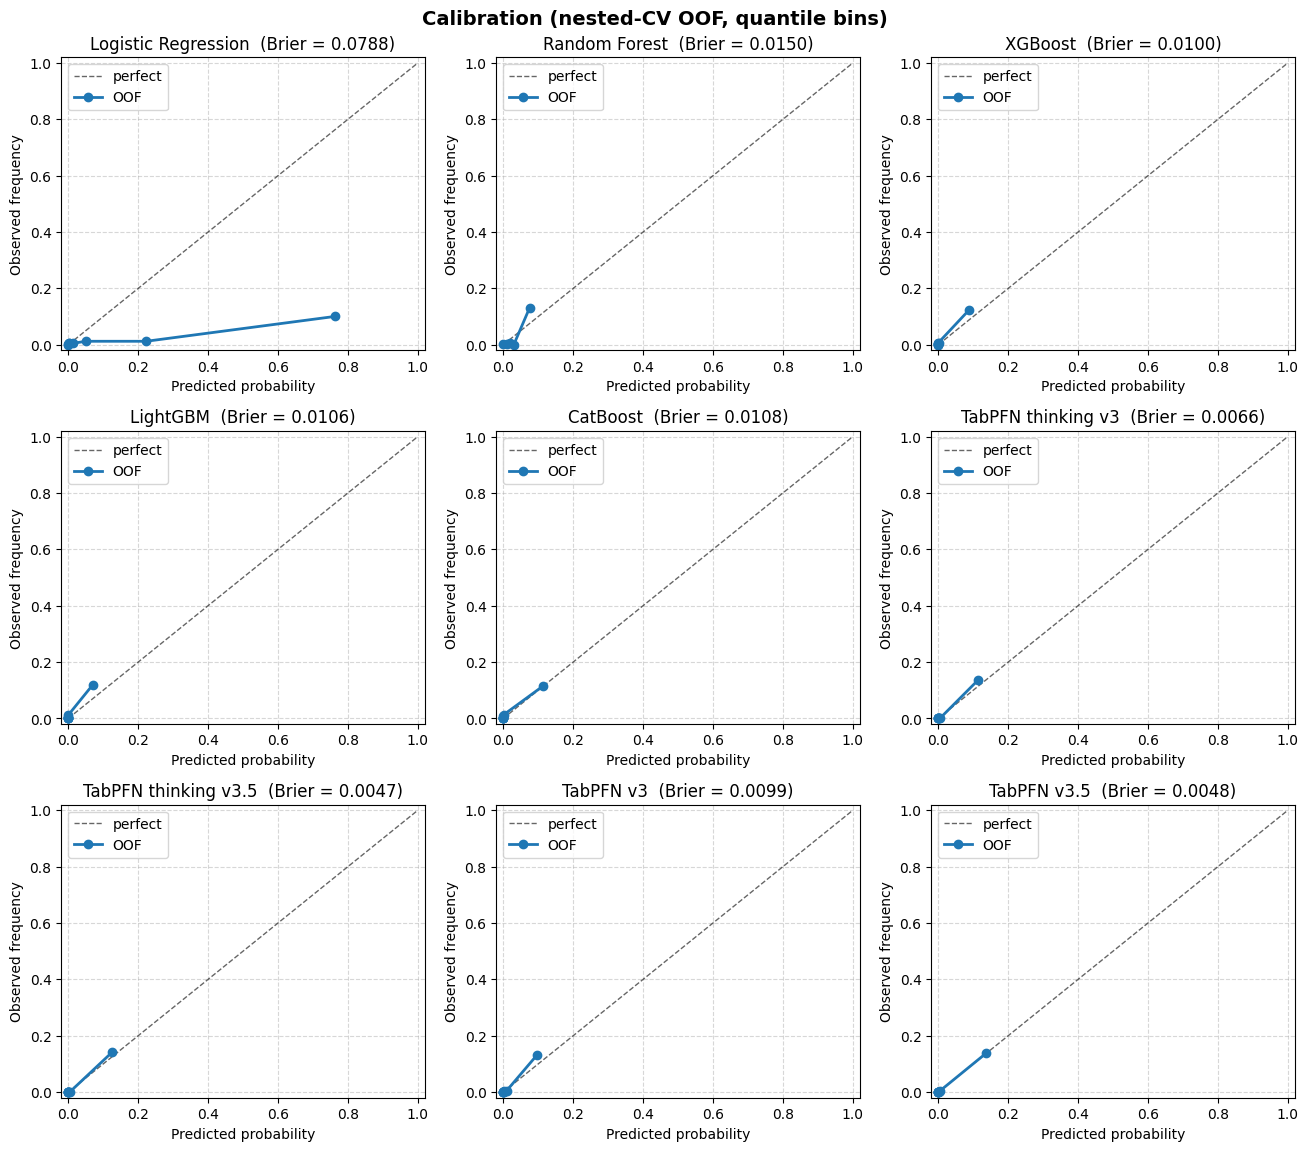

Saved calibration panel to: /kaggle/working/modeling_results/figures/calibration_curves.png
  Logistic Regression: Brier = 0.0788 | ECE (8 quantile bins) = 0.1156
  Random Forest: Brier = 0.0150 | ECE (8 quantile bins) = 0.0090
  XGBoost: Brier = 0.0100 | ECE (8 quantile bins) = 0.0066
  LightGBM: Brier = 0.0106 | ECE (8 quantile bins) = 0.0090
  CatBoost: Brier = 0.0108 | ECE (8 quantile bins) = 0.0031
  TabPFN thinking v3: Brier = 0.0066 | ECE (8 quantile bins) = 0.0036
  TabPFN thinking v3.5: Brier = 0.0047 | ECE (8 quantile bins) = 0.0028
  TabPFN v3: Brier = 0.0099 | ECE (8 quantile bins) = 0.0059
  TabPFN v3.5: Brier = 0.0048 | ECE (8 quantile bins) = 0.0003
Saved /kaggle/working/modeling_results/tables/calibration_ece.csv


In [8]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# If this kernel still holds TabPFN OOF with an inflated mean, map it back
# to the empirical prior so the calibration panel matches the other arms.
if "restore_tabpfn_empirical_prior" not in globals():
    def restore_tabpfn_empirical_prior(labels):
        names = [n for n in oof_probabilities if n.startswith("TabPFN v")]
        if not names:
            return
        y_arr = np.asarray(labels, dtype=float)
        prior = float(y_arr.mean())
        for name in names:
            p = np.asarray(oof_probabilities[name], dtype=float)
            if prior <= 0.0 or p.mean() <= 4.0 * prior:
                continue
            pi0 = 1.0 - prior
            denom = np.clip(p * prior + (1.0 - p) * pi0, 1e-12, None)
            restored = np.clip(p * prior / denom, 0.0, 1.0)
            brier_before = float(np.mean((p - y_arr) ** 2))
            brier_after = float(np.mean((restored - y_arr) ** 2))
            oof_probabilities[name] = restored
            if "fold_thresholds" in globals() and name in fold_thresholds:
                t = np.asarray(fold_thresholds[name], dtype=float)
                t_denom = np.clip(t * prior + (1.0 - t) * pi0, 1e-12, None)
                fold_thresholds[name] = np.clip(t * prior / t_denom, 0.0, 1.0).tolist()
            print(
                f"{name}: restored empirical prior "
                f"(mean {p.mean():.4f} -> {restored.mean():.4f}; "
                f"Brier {brier_before:.4f} -> {brier_after:.4f}). "
                "PR-AUC/ROC unchanged; nested hard labels unchanged."
            )

restore_tabpfn_empirical_prior(y_true_oof)


def expected_calibration_error(y_true, probs, n_bins=8, strategy="quantile"):
    """Weighted |acc-conf| ECE on the same binning as the reliability plot."""
    y_true = np.asarray(y_true, dtype=float)
    probs = np.asarray(probs, dtype=float)
    n = y_true.size
    if strategy == "quantile":
        edges = np.unique(np.quantile(probs, np.linspace(0.0, 1.0, n_bins + 1)))
    else:
        edges = np.linspace(0.0, 1.0, n_bins + 1)
    if edges.size < 3:
        return float("nan")
    idx = np.digitize(probs, edges[1:-1], right=False)
    ece = 0.0
    for b in range(edges.size - 1):
        m = idx == b
        k = int(m.sum())
        if k == 0:
            continue
        ece += (k / n) * abs(float(y_true[m].mean()) - float(probs[m].mean()))
    return float(ece)

n_models = len(oof_probabilities)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.4 * n_cols, 3.9 * n_rows))
axes = np.atleast_1d(axes).ravel()
brier_scores = {}
ece_scores = {}

for ax, (model_name, probabilities) in zip(axes, oof_probabilities.items()):
    probs = np.asarray(probabilities, dtype=float)
    brier = brier_score_loss(y_true_oof, probs)
    brier_scores[model_name] = float(brier)
    ece_scores[model_name] = expected_calibration_error(
        y_true_oof, probs, n_bins=8, strategy="quantile"
    )
    try:
        frac_pos, mean_pred = calibration_curve(
            y_true_oof, probs, n_bins=8, strategy="quantile"
        )
    except ValueError:
        frac_pos, mean_pred = calibration_curve(
            y_true_oof, probs, n_bins=5, strategy="uniform"
        )
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.6, label="perfect")
    ax.plot(mean_pred, frac_pos, "o-", lw=2, label="OOF")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.set_title(f"{model_name}  (Brier = {brier:.4f})")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(loc="upper left")

for ax in axes[n_models:]:
    ax.axis("off")

fig.suptitle("Calibration (nested-CV OOF, quantile bins)", fontsize=14, fontweight="bold")
plt.tight_layout()
cal_path = FIGURE_DIR / "calibration_curves.png"
plt.savefig(cal_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved calibration panel to: {cal_path}")
cal_rows = []
for _name, _brier in brier_scores.items():
    _ece = ece_scores[_name]
    print(f"  {_name}: Brier = {_brier:.4f} | ECE (8 quantile bins) = {_ece:.4f}")
    cal_rows.append({"model": _name, "brier": _brier, "ece_quantile_8": _ece, "n_bins": 8, "strategy": "quantile"})
pd.DataFrame(cal_rows).to_csv(TABLE_DIR / "calibration_ece.csv", index=False)
print("Saved", TABLE_DIR / "calibration_ece.csv")


## Confusion matrices

Heatmaps at each model's **F1-optimal** out-of-fold threshold (same operating point as the F1 block of the comparison table).


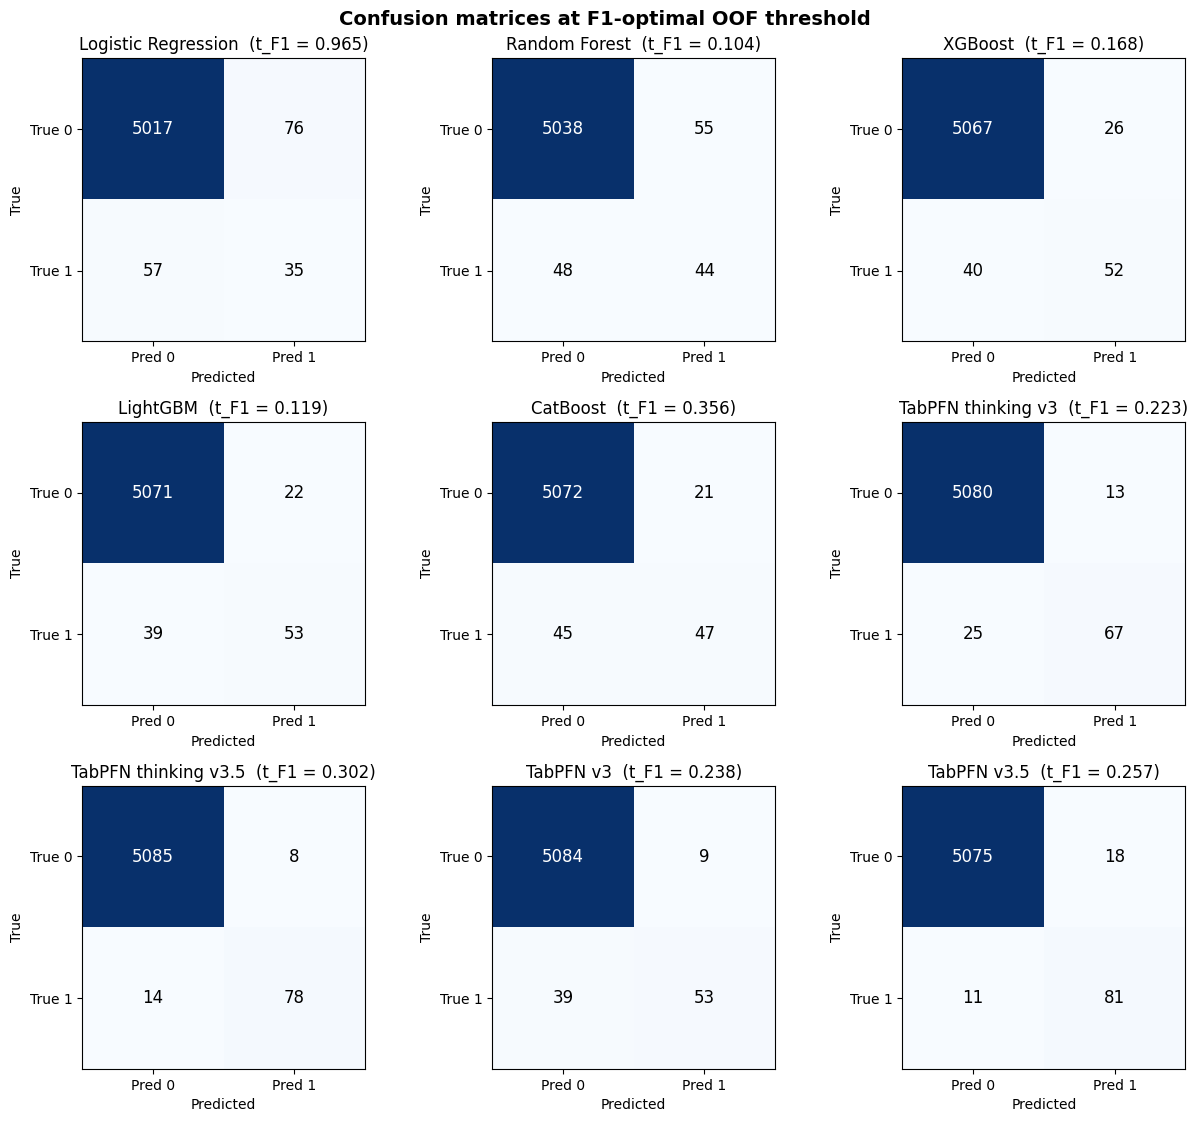

Saved confusion-matrix panel to: /kaggle/working/modeling_results/figures/confusion_matrices.png


In [9]:
cms_at_f1 = {}
f1_thresholds = {}
n_models = len(oof_probabilities)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.8 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, (model_name, probabilities) in zip(axes, oof_probabilities.items()):
    t_f1 = best_fbeta_threshold(y_true_oof, probabilities, beta=1.0)
    pred = (np.asarray(probabilities) >= t_f1).astype(int)
    cm = confusion_matrix(y_true_oof, pred, labels=[0, 1])
    cms_at_f1[model_name] = cm
    f1_thresholds[model_name] = t_f1
    ax.imshow(cm, cmap="Blues")
    for (i, j), val in np.ndenumerate(cm):
        ax.text(
            j, i, f"{val:d}", ha="center", va="center", fontsize=12,
            color="white" if val > cm.max() / 2 else "black",
        )
    ax.set_xticks([0, 1], ["Pred 0", "Pred 1"])
    ax.set_yticks([0, 1], ["True 0", "True 1"])
    ax.set_title(f"{model_name}  (t_F1 = {t_f1:.3f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

for ax in axes[n_models:]:
    ax.axis("off")

fig.suptitle("Confusion matrices at F1-optimal OOF threshold", fontsize=14, fontweight="bold")
plt.tight_layout()
cm_path = FIGURE_DIR / "confusion_matrices.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved confusion-matrix panel to: {cm_path}")


## Model comparison table

Threshold-independent ranking (pooled PR-AUC / ROC-AUC / Brier, plus fold-wise mean +/- SD) and operating-point metrics at the F1-optimal out-of-fold threshold. Nested-CV fold-specific F1 operating points are saved alongside. **NPV = TN / (TN + FN)** is printed for both the nested Table 2 cut and the optimistic pooled F1 cut.


In [10]:
from IPython.display import display
from sklearn.metrics import brier_score_loss

if "oof_fold_ids" not in globals():
    oof_fold_ids = np.zeros(len(y), dtype=int)
    _fold_splitter = StratifiedKFold(
        n_splits=OUTER_SPLITS, shuffle=True, random_state=42
    )
    for _fold, (_, _val_idx) in enumerate(_fold_splitter.split(X, y), 1):
        oof_fold_ids[_val_idx] = _fold


def metrics_at_threshold(y_true, scores, threshold):
    pred = (np.asarray(scores) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else 0.0,
        "npv": tn / (tn + fn) if (tn + fn) else 0.0,
        "f1": f1_score(y_true, pred, zero_division=0),
        "f2": fbeta_score(y_true, pred, beta=2.0, zero_division=0),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


rows = []
nested_rows = []
fold_rows = []
for model_name, probabilities in oof_probabilities.items():
    probs = np.asarray(probabilities, dtype=float)
    t_f1 = best_fbeta_threshold(y_true_oof, probs, beta=1.0)
    m_f1 = metrics_at_threshold(y_true_oof, probs, t_f1)
    fold_t = np.asarray(fold_thresholds[model_name], dtype=float)
    nested = metrics_at_threshold(
        y_true_oof, oof_binary_predictions[model_name].astype(float), 0.5
    )
    fold_pr = []
    fold_roc = []
    for fold in sorted(np.unique(oof_fold_ids)):
        mask = oof_fold_ids == fold
        pr_fold = average_precision_score(y_true_oof[mask], probs[mask])
        roc_fold = roc_auc_score(y_true_oof[mask], probs[mask])
        fold_pr.append(pr_fold)
        fold_roc.append(roc_fold)
        fold_rows.append({
            "model": model_name,
            "fold": int(fold),
            "n": int(mask.sum()),
            "n_pos": int(y_true_oof[mask].sum()),
            "pr_auc": pr_fold,
            "roc_auc": roc_fold,
        })
    rows.append({
        "model": model_name,
        "pr_auc": average_precision_score(y_true_oof, probs),
        "roc_auc": roc_auc_score(y_true_oof, probs),
        "brier": brier_score_loss(y_true_oof, probs),
        "pr_auc_mean": float(np.mean(fold_pr)),
        "pr_auc_sd": float(np.std(fold_pr, ddof=1)) if len(fold_pr) > 1 else 0.0,
        "roc_auc_mean": float(np.mean(fold_roc)),
        "roc_auc_sd": float(np.std(fold_roc, ddof=1)) if len(fold_roc) > 1 else 0.0,
        "t_f1": m_f1["threshold"],
        "acc_f1": m_f1["accuracy"],
        "prec_f1": m_f1["precision"],
        "rec_f1": m_f1["recall"],
        "spec_f1": m_f1["specificity"],
        "npv_f1": m_f1["npv"],
        "f1_at_t_f1": m_f1["f1"],
        "f2_at_t_f1": m_f1["f2"],
        "tn_f1": m_f1["tn"],
        "fp_f1": m_f1["fp"],
        "fn_f1": m_f1["fn"],
        "tp_f1": m_f1["tp"],
    })
    nested_rows.append({
        "model": model_name,
        "threshold_mean": float(fold_t.mean()),
        "threshold_sd": float(fold_t.std(ddof=1)) if fold_t.size > 1 else 0.0,
        "accuracy": nested["accuracy"],
        "precision": nested["precision"],
        "recall": nested["recall"],
        "specificity": nested["specificity"],
        "npv": nested["npv"],
        "f1": nested["f1"],
        "f2": nested["f2"],
        "tn": nested["tn"],
        "fp": nested["fp"],
        "fn": nested["fn"],
        "tp": nested["tp"],
        "pr_auc": average_precision_score(y_true_oof, probs),
        "roc_auc": roc_auc_score(y_true_oof, probs),
    })

comparison_df = pd.DataFrame(rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)
nested_df = pd.DataFrame(nested_rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)
fold_metrics_df = pd.DataFrame(fold_rows)


def _fmt_block(df, cols, float_cols, thresh_cols=()):
    out = df[cols].copy()
    for col in thresh_cols:
        out[col] = out[col].map(lambda v: f"{v:.3f}")
    for col in float_cols:
        out[col] = out[col].map(lambda v: f"{v:.4f}")
    return out


ranking_view = comparison_df.copy()
ranking_view["pr_auc_fold"] = ranking_view.apply(
    lambda r: f"{r['pr_auc_mean']:.4f}+/-{r['pr_auc_sd']:.4f}", axis=1
)
ranking_view["roc_auc_fold"] = ranking_view.apply(
    lambda r: f"{r['roc_auc_mean']:.4f}+/-{r['roc_auc_sd']:.4f}", axis=1
)

print("=== SUPER TABLE: ranking (pooled OOF + fold mean+/-SD) ===")
display(_fmt_block(
    ranking_view,
    ["model", "pr_auc", "pr_auc_fold", "roc_auc", "roc_auc_fold", "brier"],
    ["pr_auc", "roc_auc", "brier"],
))

print()
print("=== SUPER TABLE: ranking + F1-optimal OOF threshold ===")
display(_fmt_block(
    comparison_df,
    ["model", "pr_auc", "roc_auc", "t_f1", "acc_f1", "prec_f1", "rec_f1",
     "spec_f1", "npv_f1", "f1_at_t_f1", "f2_at_t_f1", "tn_f1", "fp_f1", "fn_f1", "tp_f1"],
    ["pr_auc", "roc_auc", "acc_f1", "prec_f1", "rec_f1", "spec_f1", "npv_f1", "f1_at_t_f1", "f2_at_t_f1"],
    thresh_cols=["t_f1"],
))

print()
print("=== NESTED-CV OPERATING POINT (fold-specific inner F1 thresholds) ===")
nested_display = nested_df.copy()
nested_display["threshold"] = nested_display.apply(
    lambda r: f"{r['threshold_mean']:.3f}+/-{r['threshold_sd']:.3f}", axis=1
)
display(_fmt_block(
    nested_display,
    ["model", "threshold", "accuracy", "precision", "recall", "specificity", "npv",
     "f1", "f2", "pr_auc", "roc_auc", "tn", "fp", "fn", "tp"],
    ["accuracy", "precision", "recall", "specificity", "npv", "f1", "f2", "pr_auc", "roc_auc"],
))

print()
print("=== FOLD-WISE RANKING METRICS ===")
fold_show = fold_metrics_df.copy()
for col in ["pr_auc", "roc_auc"]:
    fold_show[col] = fold_show[col].map(lambda v: f"{v:.4f}")
display(fold_show)

cm_table = (
    comparison_df[["model", "t_f1", "tn_f1", "fp_f1", "fn_f1", "tp_f1"]]
    .rename(columns={"t_f1": "threshold", "tn_f1": "tn", "fp_f1": "fp", "fn_f1": "fn", "tp_f1": "tp"})
    .assign(strategy="f1")
    [["model", "strategy", "threshold", "tn", "fp", "fn", "tp"]]
)

comparison_path = TABLE_DIR / "model_comparison.csv"
nested_path = TABLE_DIR / "nested_cv_operating_point.csv"
cm_counts_path = TABLE_DIR / "confusion_counts.csv"
fold_path = TABLE_DIR / "fold_metrics.csv"
comparison_df.to_csv(comparison_path, index=False)
nested_df.to_csv(nested_path, index=False)
cm_table.to_csv(cm_counts_path, index=False)
fold_metrics_df.to_csv(fold_path, index=False)
print()
print("Nested NPV = TN/(TN+FN) [quote Table 2]:")
for _r in nested_df.itertuples(index=False):
    print(
        f"  {_r.model}: NPV={_r.npv:.4f}  ({int(_r.tn)}/{int(_r.tn) + int(_r.fn)})"
    )
print()
print("Saved tables to:")
print(" ", comparison_path)
print(" ", nested_path)
print(" ", cm_counts_path)
print(" ", fold_path)


=== SUPER TABLE: ranking (pooled OOF + fold mean+/-SD) ===


,model,pr_auc,pr_auc_fold,roc_auc,roc_auc_fold,brier
0,TabPFN thinking v3.5,0.9212,0.9227+/-0.0423,0.9963,0.9965+/-0.0027,0.0047
1,TabPFN v3.5,0.8957,0.8995+/-0.0528,0.9916,0.9922+/-0.0066,0.0048
2,TabPFN thinking v3,0.8319,0.8335+/-0.0658,0.9834,0.9843+/-0.0105,0.0066
3,TabPFN v3,0.7150,0.7286+/-0.0319,0.9731,0.9741+/-0.0125,0.0099
4,XGBoost,0.6322,0.6448+/-0.0880,0.9374,0.9366+/-0.0371,0.0100
5,LightGBM,0.6271,0.6248+/-0.0990,0.9444,0.9458+/-0.0332,0.0106
6,CatBoost,0.5707,0.5867+/-0.0494,0.9404,0.9418+/-0.0168,0.0108
7,Random Forest,0.3506,0.3843+/-0.0792,0.8883,0.8880+/-0.0228,0.0150
8,Logistic Regression,0.2596,0.2836+/-0.1106,0.8651,0.8671+/-0.0479,0.0788



=== SUPER TABLE: ranking + F1-optimal OOF threshold ===


,model,pr_auc,roc_auc,t_f1,acc_f1,prec_f1,rec_f1,spec_f1,npv_f1,f1_at_t_f1,f2_at_t_f1,tn_f1,fp_f1,fn_f1,tp_f1
0,TabPFN thinking v3.5,0.9212,0.9963,0.302,0.9958,0.9070,0.8478,0.9984,0.9973,0.8764,0.8590,5085,8,14,78
1,TabPFN v3.5,0.8957,0.9916,0.257,0.9944,0.8182,0.8804,0.9965,0.9978,0.8482,0.8672,5075,18,11,81
2,TabPFN thinking v3,0.8319,0.9834,0.223,0.9927,0.8375,0.7283,0.9974,0.9951,0.7791,0.7478,5080,13,25,67
3,TabPFN v3,0.7150,0.9731,0.238,0.9907,0.8548,0.5761,0.9982,0.9924,0.6883,0.6163,5084,9,39,53
4,XGBoost,0.6322,0.9374,0.168,0.9873,0.6667,0.5652,0.9949,0.9922,0.6118,0.5830,5067,26,40,52
5,LightGBM,0.6271,0.9444,0.119,0.9882,0.7067,0.5761,0.9957,0.9924,0.6347,0.5982,5071,22,39,53
6,CatBoost,0.5707,0.9404,0.356,0.9873,0.6912,0.5109,0.9959,0.9912,0.5875,0.5390,5072,21,45,47
7,Random Forest,0.3506,0.8883,0.104,0.9801,0.4444,0.4783,0.9892,0.9906,0.4607,0.4711,5038,55,48,44
8,Logistic Regression,0.2596,0.8651,0.965,0.9743,0.3153,0.3804,0.9851,0.9888,0.3448,0.3653,5017,76,57,35



=== NESTED-CV OPERATING POINT (fold-specific inner F1 thresholds) ===


,model,threshold,accuracy,precision,recall,specificity,npv,f1,f2,pr_auc,roc_auc,tn,fp,fn,tp
0,TabPFN thinking v3.5,0.318+/-0.059,0.9952,0.8851,0.8370,0.9980,0.9971,0.8603,0.8462,0.9212,0.9963,5083,10,15,77
1,TabPFN v3.5,0.386+/-0.061,0.9940,0.8675,0.7826,0.9978,0.9961,0.8229,0.7982,0.8957,0.9916,5082,11,20,72
2,TabPFN thinking v3,0.271+/-0.055,0.9929,0.8767,0.6957,0.9982,0.9945,0.7758,0.7256,0.8319,0.9834,5084,9,28,64
3,TabPFN v3,0.183+/-0.036,0.9886,0.7089,0.6087,0.9955,0.9929,0.6550,0.6264,0.7150,0.9731,5070,23,36,56
4,XGBoost,0.238+/-0.104,0.9867,0.6575,0.5217,0.9951,0.9914,0.5818,0.5442,0.6322,0.9374,5068,25,44,48
5,LightGBM,0.076+/-0.037,0.9855,0.5934,0.5870,0.9927,0.9925,0.5902,0.5882,0.6271,0.9444,5056,37,38,54
6,CatBoost,0.170+/-0.064,0.9826,0.5093,0.5978,0.9896,0.9927,0.5500,0.5777,0.5707,0.9404,5040,53,37,55
7,Random Forest,0.112+/-0.016,0.9801,0.4421,0.4565,0.9896,0.9902,0.4492,0.4536,0.3506,0.8883,5040,53,50,42
8,Logistic Regression,0.964+/-0.013,0.9740,0.3028,0.3587,0.9851,0.9884,0.3284,0.3459,0.2596,0.8651,5017,76,59,33



=== FOLD-WISE RANKING METRICS ===


,model,fold,n,n_pos,pr_auc,roc_auc
0,Logistic Regression,1,1037,18,0.1769,0.8178
1,Logistic Regression,2,1037,18,0.2549,0.9193
2,Logistic Regression,3,1037,18,0.2013,0.8170
3,Logistic Regression,4,1037,19,0.3369,0.9050
4,Logistic Regression,5,1037,19,0.4481,0.8764
5,Random Forest,1,1037,18,0.4061,0.9045
6,Random Forest,2,1037,18,0.4443,0.8728
7,Random Forest,3,1037,18,0.3623,0.8558
8,Random Forest,4,1037,19,0.2576,0.9091
9,Random Forest,5,1037,19,0.4512,0.8978



Nested NPV = TN/(TN+FN) [quote Table 2]:
  TabPFN thinking v3.5: NPV=0.9971  (5083/5098)
  TabPFN v3.5: NPV=0.9961  (5082/5102)
  TabPFN thinking v3: NPV=0.9945  (5084/5112)
  TabPFN v3: NPV=0.9929  (5070/5106)
  XGBoost: NPV=0.9914  (5068/5112)
  LightGBM: NPV=0.9925  (5056/5094)
  CatBoost: NPV=0.9927  (5040/5077)
  Random Forest: NPV=0.9902  (5040/5090)
  Logistic Regression: NPV=0.9884  (5017/5076)

Saved tables to:
  /kaggle/working/modeling_results/tables/model_comparison.csv
  /kaggle/working/modeling_results/tables/nested_cv_operating_point.csv
  /kaggle/working/modeling_results/tables/confusion_counts.csv
  /kaggle/working/modeling_results/tables/fold_metrics.csv


## Threshold sweeps (best model)

Threshold and FP/FN sweeps for the **best model by PR-AUC**, using nested-CV out-of-fold scores.

- **f1** marks the F1-maximising threshold
- FP vs FN traces the same sweep and highlights the chosen operating point


Best model by PR-AUC: TabPFN thinking v3.5 (AP = 0.9212)


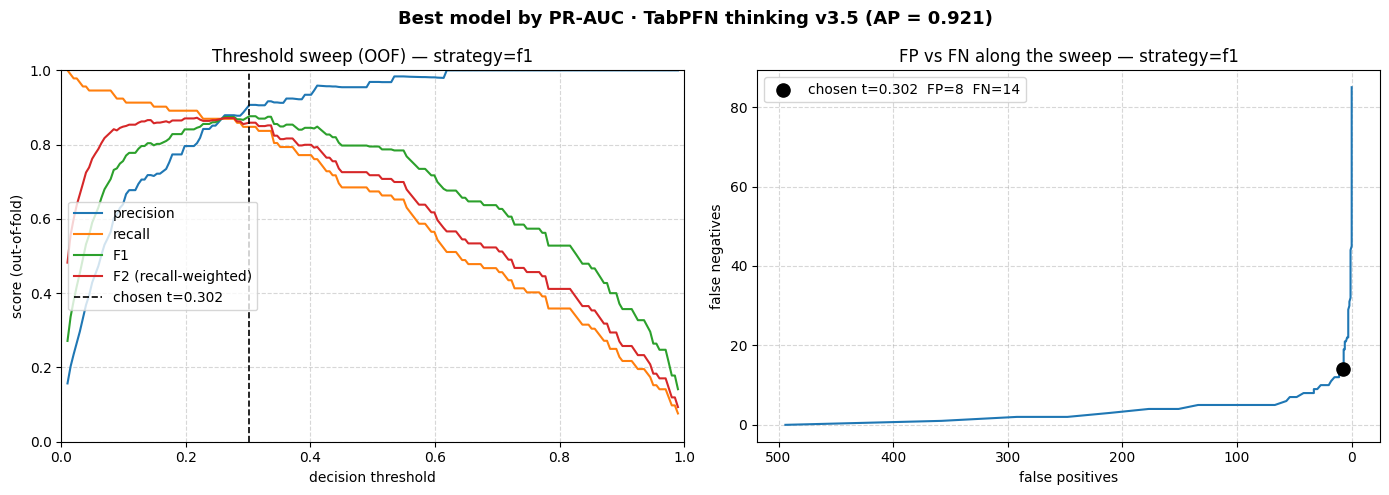

Saved figures panel to: /kaggle/working/modeling_results/figures/best_model_threshold_fpfn_panel.png
Saved sweep tables to:
  /kaggle/working/modeling_results/tables/best_model_threshold_sweep.csv
  /kaggle/working/modeling_results/tables/best_model_operating_points.csv
  f1 threshold = 0.302


In [11]:
best_name, best_ap = max(
    (
        (name, average_precision_score(y_true_oof, probabilities))
        for name, probabilities in oof_probabilities.items()
    ),
    key=lambda item: item[1],
)
best_scores = np.asarray(oof_probabilities[best_name], dtype=float)
print(f"Best model by PR-AUC: {best_name} (AP = {best_ap:.4f})")

grid = THRESHOLD_GRID
precisions = np.empty(grid.size)
recalls = np.empty(grid.size)
f1_values = np.empty(grid.size)
f2_values = np.empty(grid.size)
false_positives = np.empty(grid.size, dtype=int)
false_negatives = np.empty(grid.size, dtype=int)
npvs = np.empty(grid.size)
for i, threshold in enumerate(grid):
    pred = (best_scores >= threshold).astype(int)
    precisions[i] = precision_score(y_true_oof, pred, zero_division=0)
    recalls[i] = recall_score(y_true_oof, pred, zero_division=0)
    f1_values[i] = f1_score(y_true_oof, pred, zero_division=0)
    f2_values[i] = fbeta_score(y_true_oof, pred, beta=2.0, zero_division=0)
    tn, fp, fn, _ = confusion_matrix(y_true_oof, pred, labels=[0, 1]).ravel()
    false_positives[i] = int(fp)
    false_negatives[i] = int(fn)
    npvs[i] = float(tn / (tn + fn)) if (tn + fn) else 0.0

chosen = {
    "f1": float(grid[int(np.argmax(f1_values))]),
}


def _plot_threshold_sweep(ax, strategy, chosen_t):
    ax.plot(grid, precisions, label="precision")
    ax.plot(grid, recalls, label="recall")
    ax.plot(grid, f1_values, label="F1")
    ax.plot(grid, f2_values, label="F2 (recall-weighted)")
    ax.axvline(chosen_t, color="k", ls="--", lw=1.2, label=f"chosen t={chosen_t:.3f}")
    ax.set_xlabel("decision threshold")
    ax.set_ylabel("score (out-of-fold)")
    ax.set_title(f"Threshold sweep (OOF) — strategy={strategy}")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.legend(loc="center left")
    ax.grid(True, linestyle="--", alpha=0.5)


def _plot_fp_fn_sweep(ax, strategy, chosen_t):
    ax.plot(false_positives, false_negatives, "-", lw=1.5)
    idx = int(np.argmin(np.abs(grid - chosen_t)))
    ax.scatter(
        [false_positives[idx]],
        [false_negatives[idx]],
        s=90,
        color="k",
        zorder=5,
        label=f"chosen t={chosen_t:.3f}  FP={false_positives[idx]}  FN={false_negatives[idx]}",
    )
    ax.set_xlabel("false positives")
    ax.set_ylabel("false negatives")
    ax.set_title(f"FP vs FN along the sweep — strategy={strategy}")
    ax.invert_xaxis()
    ax.legend(loc="best")
    ax.grid(True, linestyle="--", alpha=0.5)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_plot_threshold_sweep(axes[0], "f1", chosen["f1"])
_plot_fp_fn_sweep(axes[1], "f1", chosen["f1"])
fig.suptitle(
    f"Best model by PR-AUC · {best_name} (AP = {best_ap:.3f})",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
panel_path = FIGURE_DIR / "best_model_threshold_fpfn_panel.png"
plt.savefig(panel_path, dpi=300, bbox_inches="tight")
plt.show()

sweep_table = pd.DataFrame({
    "threshold": grid,
    "precision": precisions,
    "recall": recalls,
    "npv": npvs,
    "f1": f1_values,
    "f2": f2_values,
    "fp": false_positives,
    "fn": false_negatives,
})
sweep_csv = TABLE_DIR / "best_model_threshold_sweep.csv"
chosen_csv = TABLE_DIR / "best_model_operating_points.csv"
sweep_table.to_csv(sweep_csv, index=False)
pd.DataFrame(
    [
        {"model": best_name, "strategy": "f1", "threshold": chosen["f1"]},
    ]
).to_csv(chosen_csv, index=False)

print(f"Saved figures panel to: {panel_path}")
print("Saved sweep tables to:")
print(" ", sweep_csv)
print(" ", chosen_csv)
print(f"  f1 threshold = {chosen['f1']:.3f}")
